## Signal Seasonality Check

1. Pull panel data.
2. Test out reversal signals.

We will be focusing here on signal construction for our first strategy. 

In [2]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import time
from collections import Counter
import os
import pickle
import matplotlib.pyplot as plt

os.chdir('/Users/muditlam/Desktop/PythonJupyterCode/cryptoStatArbProject')

from quantlib import (
    rank_demean_normalize, compute_turnover, apply_costs,
    get_stats, factor_regression, drawdown,
    BARS_PER_YEAR_4H, DEFAULT_COST_BPS_MARKET,
)

print("Working directory:", os.getcwd())

PROJECT_DIR = os.path.dirname(os.path.abspath('DataPipeline.ipynb'))
PANEL_DATA_PATH = os.path.join(PROJECT_DIR, 'data', 'binance_ohlcv_panel_4h.pkl')

print(PANEL_DATA_PATH)
os.makedirs(os.path.dirname(PANEL_DATA_PATH), exist_ok=True)
print(f"Save path: {PANEL_DATA_PATH}")

FREQ = '4h'
START_TS = '2019-01-01'

panels = pickle.load(open(PANEL_DATA_PATH, 'rb'))

px = panels['px']
ret = panels['ret']
dvol = panels['dvol']
taker_buy_dvol = panels['taker_buy_dvol']
num_trades = panels['num_trades']
high_px = panels['high_px']
low_px = panels['low_px']
close_px = panels['close_px']
universe = panels['universe']
universe_daily = panels['universe_daily']
universe_monthly = panels['universe_monthly']
candidate_symbols = panels['candidate_symbols']

print(f"Loaded pickle. px: {px.shape}, ret: {ret.shape})")


Working directory: /Users/muditlam/Desktop/PythonJupyterCode/classProject
/Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Save path: /Users/muditlam/Desktop/PythonJupyterCode/classProject/data/binance_ohlcv_panel_4h.pkl
Loaded pickle. px: (14417, 193), ret: (14417, 193))


## Side trip To check Seasonality

#### Does our data show that the 20:00 to 24:00 UTC 4 hr bar have higher returns due to all exchanges being closed at between 21:00 to 23:00 UTC? 
#### NOTE: We really should check this with hourly data but for now this works.

1. Grab BTC 4h returns. 
1. Group by hour-of-day
1. build a dataframe with one row per hour and columns for mean, std, n, t_stat, mean_bps, and ann_ret
1. print table
1. Compare 20:00 bar to rest of bars combined and ask if its better than the average bar. This will nead a t_stat_diff.
1. Plot series.
1. Plot annualized version as well.



In [3]:
btc_ret = ret['BTCUSDT'].dropna()
group_by_4h = btc_ret.groupby(btc_ret.index.hour)
analysis = group_by_4h.agg(['mean', 'std', 'count'])
analysis['t_stat_zero'] = analysis['mean'] / (analysis['std'] / np.sqrt(analysis['count']))
analysis['ann_ret'] = analysis['mean'] * BARS_PER_YEAR_4H
analysis

,mean,std,count,t_stat_zero,ann_ret
0,-0.000248,0.012459,2403,-0.977325,-0.543978
4,0.000143,0.010304,2402,0.678855,0.312571
8,0.000312,0.012201,2402,1.252394,0.682812
12,0.000374,0.015279,2403,1.198932,0.818403
16,0.000069,0.013474,2403,0.250344,0.150699
20,0.000703,0.013028,2403,2.643850,1.538815


Results show the highest t_stat compared to 0 at the 20 hour mark. This is for 4 hour windows so its likely the real 21 to 23 time is even higher. Returns are higher as well during this window.

In [4]:
btc_ret_20 = btc_ret[btc_ret.index.hour == 20]
btc_ret_rest = btc_ret[btc_ret.index.hour != 20]

analysis_with_others = {}
analysis_with_others['mean_diff'] = btc_ret_20.mean() - btc_ret_rest.mean()
analysis_with_others['pooled_SE'] = np.sqrt(btc_ret_20.std()**2/btc_ret_20.count() + btc_ret_rest.std()**2/btc_ret_rest.count())
analysis_with_others['t_stat_diff'] = analysis_with_others['mean_diff'] / analysis_with_others['pooled_SE']
analysis_with_others = pd.DataFrame(columns=['mean_diff', 'pooled_SE', 't_stat_diff'], data=[analysis_with_others.values()])
print(analysis_with_others)


   mean_diff  pooled_SE  t_stat_diff
0   0.000573    0.00029      1.97247


T-stat of 2 could still be random chance. I want to try this with hourly data. Also, lets compare weekdays vs weekends.

<BarContainer object of 6 artists>

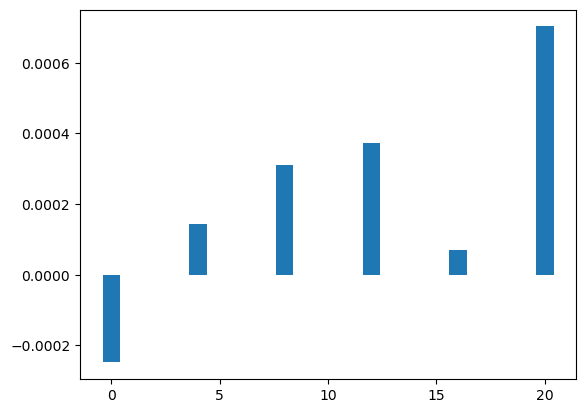

In [5]:
plt.bar(analysis.index, analysis['mean'])

In [10]:
rows = btc_ret.index.day_of_week
cols = btc_ret.index.hour
value = btc_ret.groupby([rows, cols]).mean().unstack()
t_stat = value / (btc_ret.groupby([rows, cols]).std().unstack() / np.sqrt(btc_ret.groupby([rows, cols]).count().unstack()))
print(t_stat)

         0         4         8         12        16        20
0 -0.483635  1.146408 -0.669463  2.398105 -0.233841  2.384281
1 -0.278923  0.402434  0.893172 -1.256752 -0.188289  2.189667
2 -0.430804  1.655180  1.969532  1.423254  1.169469  1.007536
3 -1.242138  0.526731 -0.194371 -0.545555 -1.302725 -0.749474
4 -0.510650 -1.216205  1.595967  0.107468  0.714566  1.208896
5  1.314192 -2.069666 -0.475687  2.281890 -0.135789  0.236895
6 -0.683996  1.271971 -0.166206 -1.333377  0.752392  0.971425


Testing for Monday and Tuesday only (This is a bit of P-hacking):

In [26]:
btc_ret_mon_tues = btc_ret[btc_ret.index.day_of_week.isin([0, 1])]
group_by_4h_mon_tues = btc_ret_mon_tues.groupby(btc_ret_mon_tues.index.hour)
analysis_mon_tues = group_by_4h_mon_tues.agg(['mean', 'std', 'count'])
analysis_mon_tues['t_stat_zero'] = analysis_mon_tues['mean'] / (analysis_mon_tues['std'] / np.sqrt(analysis_mon_tues['count']))
analysis_mon_tues['ann_ret'] = analysis_mon_tues['mean'] * BARS_PER_YEAR_4H
print(analysis_mon_tues)

        mean       std  count  t_stat_zero   ann_ret
0  -0.000310  0.014652    687    -0.554325 -0.678641
4   0.000498  0.011144    687     1.171259  1.090620
8   0.000053  0.012075    687     0.115495  0.116527
12  0.000689  0.017813    688     1.014892  1.509421
16 -0.000177  0.015642    688    -0.295980 -0.386545
20  0.001630  0.013222    688     3.233477  3.569534


In [27]:
# Comparing with every other return datapoint.

mask_signal = (btc_ret.index.hour == 20) & (btc_ret.index.day_of_week.isin([0, 1]))
btc_ret_20_mon_tues = btc_ret[mask_signal]
btc_ret_rest_mon_tues = btc_ret[~mask_signal]

analysis_with_others_mon_tues = {}
analysis_with_others_mon_tues['mean_diff'] = btc_ret_20_mon_tues.mean() - btc_ret_rest_mon_tues.mean()
analysis_with_others_mon_tues['pooled_SE'] = np.sqrt(btc_ret_20_mon_tues.std()**2/btc_ret_20_mon_tues.count() + btc_ret_rest_mon_tues.std()**2/btc_ret_rest_mon_tues.count())
analysis_with_others_mon_tues['t_stat_diff'] = analysis_with_others_mon_tues['mean_diff'] / analysis_with_others_mon_tues['pooled_SE']
analysis_with_others_mon_tues = pd.DataFrame(columns=['mean_diff', 'pooled_SE', 't_stat_diff'], data=[analysis_with_others_mon_tues.values()])
print(analysis_with_others_mon_tues)


   mean_diff  pooled_SE  t_stat_diff
0   0.001475   0.000516     2.859373


Let's check to see if this is a consistent signal YoY or there was a bull run affecting the numbers in one year.

In [28]:
signal=btc_ret_20_mon_tues
signal_yoy = signal.groupby(signal.index.year).agg(['mean', 'count', 'std'])
signal_yoy = signal_yoy[signal_yoy['count'] >= 104]
signal_yoy['t_stat'] = signal_yoy['mean'] / (signal_yoy['std'] / np.sqrt(signal_yoy['count']))
signal_yoy['ann_ret'] = signal_yoy['mean'] * signal_yoy['count']
signal_yoy['sharpe'] = signal_yoy['mean'] / signal_yoy['std'] * np.sqrt(signal_yoy['count'])
print(signal_yoy)

          mean  count       std    t_stat   ann_ret    sharpe
2020  0.003639    104  0.012053  3.078844  0.378433  3.078844
2021  0.001363    104  0.021868  0.635805  0.141789  0.635805
2022  0.002362    104  0.012538  1.921381  0.245674  1.921381
2023  0.001096    104  0.009097  1.228277  0.113955  1.228277
2024  0.000749    106  0.012131  0.636004  0.079432  0.636004
2025  0.000713    104  0.008926  0.814259  0.074117  0.814259


## Final Thoughts

- The signal for 20 to 24 seems strongest for Mondays and Tuesdays (p-hacking)
- Intuitively, it could just be institutions resuming trading but I'm not sure yet
- The YoY breakdown shows that 2020 had a very strong signal but 2021 was weak. This could be due to the fact that 2020 had a very strong bull market and 2021 had a more sideways market. 
- This is a good sign that the signal is not just noise and has some predictive power. However, we need to be careful about overfitting to this specific time period.
- The other thing to note is the t_stat is strongest in 2020 with insane returns due to the bull market. We should test out 2022 to 2024 as well. 
- Sharpe deteriates over time. It collapsed and return annualized also collapsed. With our 20 bps execution/slippage, we are kind of screwed.
